# Detecção de Discurso de Ódio em Português com Regressão Logística
Este notebook utiliza a base de dados **HateBR** para treinar um modelo de **Regressão Logística** com vetorização **TF-IDF**, como parte de um estudo comparativo de abordagens para detecção de discurso de ódio em textos em português.

**Configurações padronizadas entre todos os modelos:**
- Dataset: HateBR (carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Pré-processamento: lowercase, remoção de URLs, menções, pontuação e números
- Métrica principal: F1-score macro

## 1. Importações

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## 2. Carregamento da base de dados
A base HateBR é carregada diretamente do repositório no GitHub. Contém 7.000 comentários em português, anotados por três anotadores, com rótulo binário final: `1` = discurso de ódio, `0` = não ódio.

In [11]:
url = 'https://raw.githubusercontent.com/franciellevargas/HateBR/refs/heads/main/dataset/HateBR.csv'
df = pd.read_csv(url)

print(f'Total de amostras: {len(df)}')
print(f'Distribuição de classes:\n{df["label_final"].value_counts()}')
df[['comentario', 'label_final']].head()

Total de amostras: 7000
Distribuição de classes:
label_final
1    3500
0    3500
Name: count, dtype: int64


,comentario,label_final
0,Mais um lixo,1
1,Essa nao tem vergonha na cara!!,1
2,Essa mulher é doente.pilantra!,1
3,Comunista safada...,1
4,Vagabunda. Comunista. Mentirosa. O povo chilen...,1


## 3. Pré-processamento de texto
Aplicamos limpeza padronizada: lowercase, remoção de URLs, menções (@), hashtags (#), pontuação e tokens numéricos.

> **Nota:** Stopwords não foram removidas, pois palavras funcionais podem carregar valor contextual relevante para detecção de discurso de ódio.

In [12]:
def preprocess_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove menções e hashtags
    text = re.sub(r'\@\w+|\#\w+', '', text)
    # Substitui pontuação por espaço (evita fusão de palavras como 'doente.pilantra')
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    # Remove tokens numéricos
    text = re.sub(r'\w*\d\w*', '', text)
    # Remove espaços extras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['comentario'].apply(preprocess_text)

# Verificação: exemplo antes e depois
df[['comentario', 'text_clean']].head()

,comentario,text_clean
0,Mais um lixo,mais um lixo
1,Essa nao tem vergonha na cara!!,essa nao tem vergonha na cara
2,Essa mulher é doente.pilantra!,essa mulher é doente pilantra
3,Comunista safada...,comunista safada
4,Vagabunda. Comunista. Mentirosa. O povo chilen...,vagabunda comunista mentirosa o povo chileno n...


## 4. Vetorização com TF-IDF
Usamos `TfidfVectorizer` com `max_features=10000` e bigramas (`ngram_range=(1,2)`), configuração padronizada com o modelo SVM para comparação justa.

In [13]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['text_clean'])
y = df['label_final']

print(f'Dimensão do vetor TF-IDF: {X.shape}')

Dimensão do vetor TF-IDF: (7000, 10000)


## 5. Divisão treino/teste
Split 80/20 com `stratify=y` para garantir proporção balanceada de classes nos dois conjuntos.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treinamento: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')

Treinamento: 5600 amostras
Teste: 1400 amostras


## 6. Treinamento do modelo
Utilizamos Regressão Logística com `class_weight='balanced'` para lidar com eventuais desbalanceamentos de classe, e `max_iter=1000` para garantir convergência.

In [16]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 7. Avaliação do modelo
Métricas: precisão, recall, **F1-score macro** (métrica principal do estudo) e matriz de confusão.

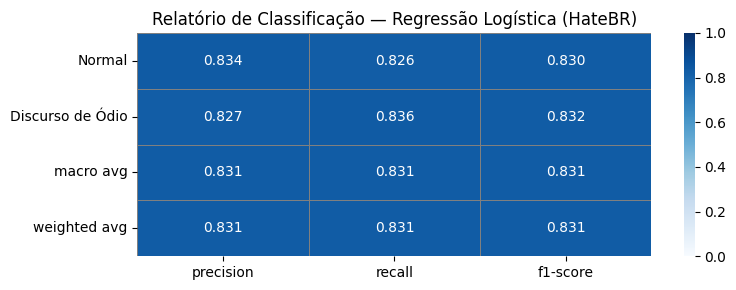

F1-score Macro: 0.8307


In [33]:
y_pred = model.predict(X_test)

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Discurso de Ódio'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação — Regressão Logística (HateBR)')
plt.tight_layout()
plt.savefig('report_lr_hatebr.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

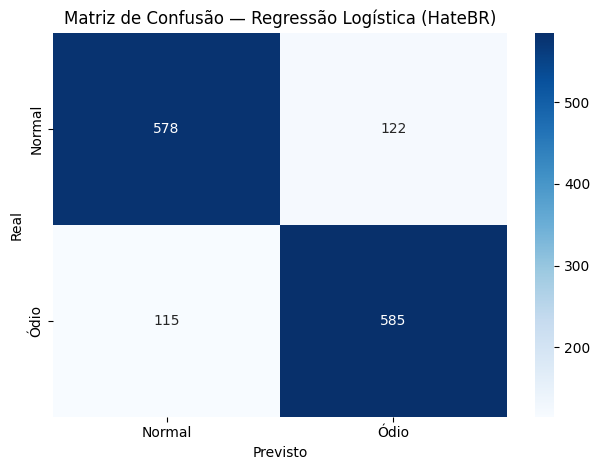

In [35]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ódio'],
            yticklabels=['Normal', 'Ódio'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão — Regressão Logística (HateBR)')
plt.tight_layout()
plt.show()

## 8. Palavras mais relevantes por classe
Visualizamos os tokens com maior peso no modelo, o que ajuda a interpretar o que o classificador aprendeu.

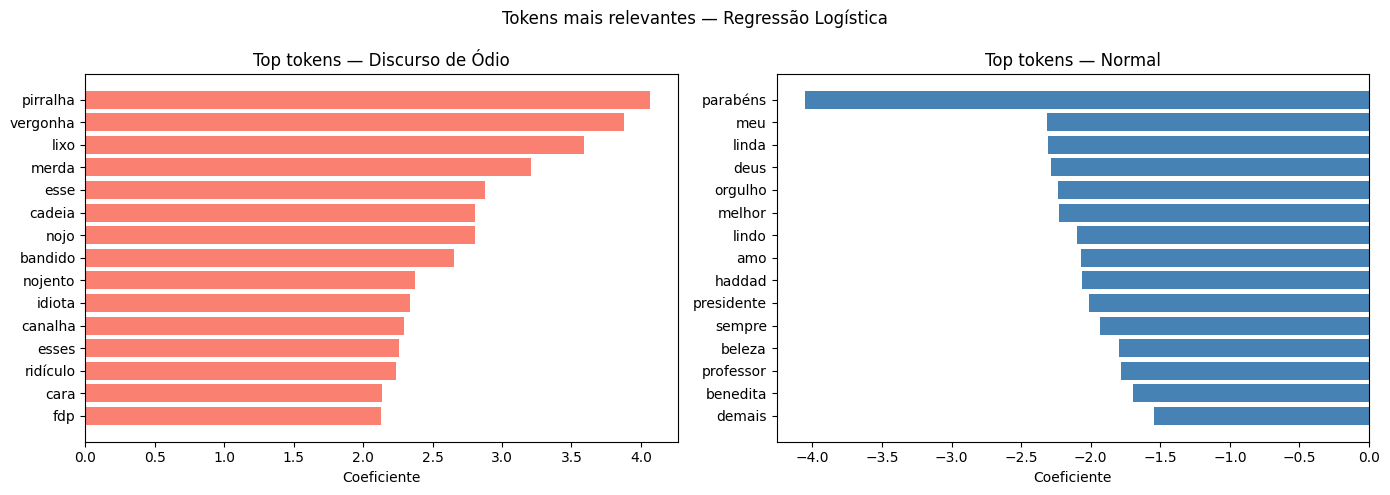

In [19]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]
top_n = 15

top_hate = np.argsort(coef)[-top_n:][::-1]
top_normal = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_hate][::-1], coef[top_hate][::-1], color='salmon')
axes[0].set_title('Top tokens — Discurso de Ódio')
axes[0].set_xlabel('Coeficiente')

axes[1].barh(feature_names[top_normal][::-1], coef[top_normal][::-1], color='steelblue')
axes[1].set_title('Top tokens — Normal')
axes[1].set_xlabel('Coeficiente')

plt.suptitle('Tokens mais relevantes — Regressão Logística')
plt.tight_layout()
plt.show()

In [34]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, os as _os
from sklearn.model_selection import train_test_split as _tts

# Reconstrução dos textos de teste (mesmo split determinístico)
_, _idx = _tts(np.arange(len(df)), test_size=0.2,
               stratify=df['label_final'], random_state=42)
_texts = df['comentario'].values[_idx]

# Converter y_test para numpy (é pandas Series em LogReg/SVM)
_y_test = np.array(y_test)
_y_pred = np.array(y_pred)

_fp_idx = np.where((_y_test == 0) & (_y_pred == 1))[0]
_fn_idx = np.where((_y_test == 1) & (_y_pred == 0))[0]

_rng = np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'Regressão Logística', 'dataset': 'HateBR',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'Regressão Logística', 'dataset': 'HateBR',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'Regressão Logística') & (_df_existing['dataset'] == 'HateBR'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 180 linhas
